In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
# Load dataset
file_path = "Learner_Raw(in).csv"
df = pd.read_csv(file_path)

In [3]:
# Data Cleaning
## Handling missing values
df.fillna("Unknown", inplace=True)

In [4]:
# Standardizing text columns
for col in ['country', 'degree', 'institution', 'major']:
    df[col] = df[col].str.title()

In [5]:
# Removing duplicates
df.drop_duplicates(inplace=True)


In [6]:
# Visualization Setup
plt.style.use('seaborn-darkgrid')
sns.set_palette("viridis")


C:\Users\Chandan N\AppData\Local\Temp\ipykernel_5628\2275668586.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


***Bar Plot (Country-wise Degree Distribution)***

C:\Users\Chandan N\AppData\Local\Temp\ipykernel_5628\2136512254.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['country'], order=df['country'].value_counts().index[:10], palette='coolwarm')


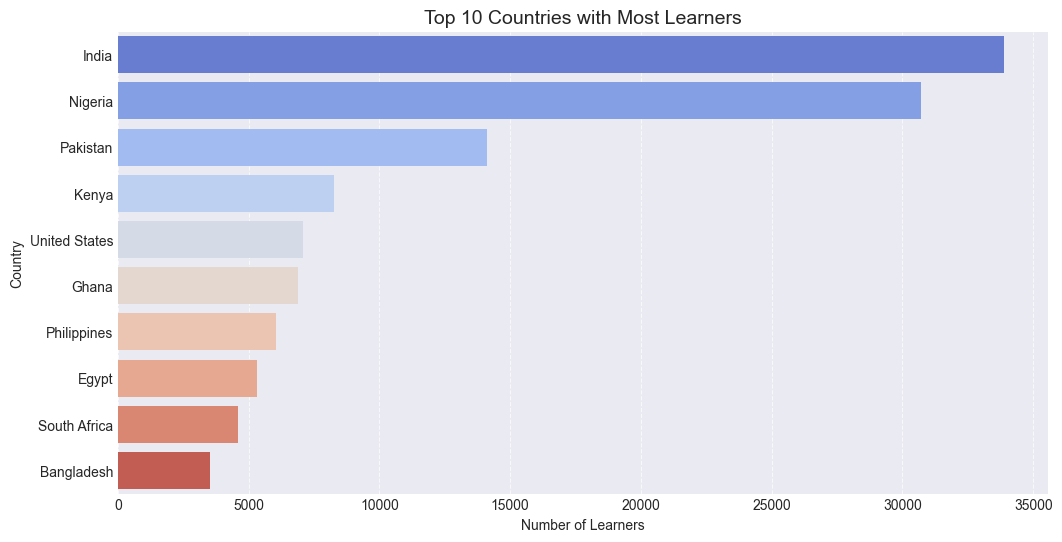

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(y=df['country'], order=df['country'].value_counts().index[:10], palette='coolwarm')
plt.title('Top 10 Countries with Most Learners', fontsize=14)
plt.xlabel('Number of Learners')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

***Pie Chart (Degree Distribution)***

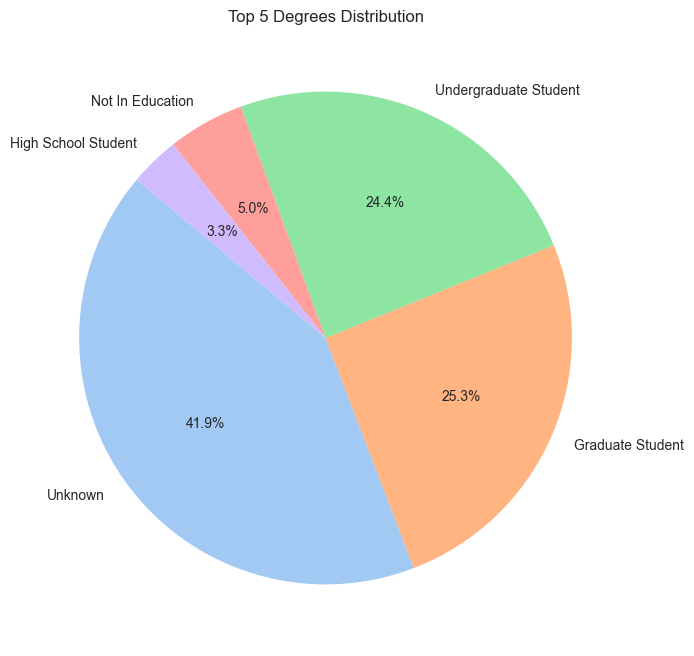

In [8]:
degree_counts = df['degree'].value_counts().head(5)
plt.figure(figsize=(8, 8))
plt.pie(degree_counts, labels=degree_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Top 5 Degrees Distribution")
plt.show()


***Word Cloud (Majors)***

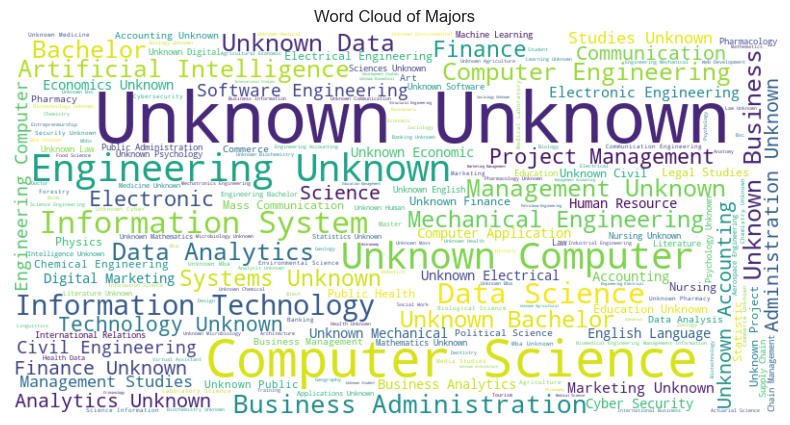

In [9]:
text = ' '.join(df['major'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Majors")
plt.show()

***Box Plot (Number of Learners per Country)***

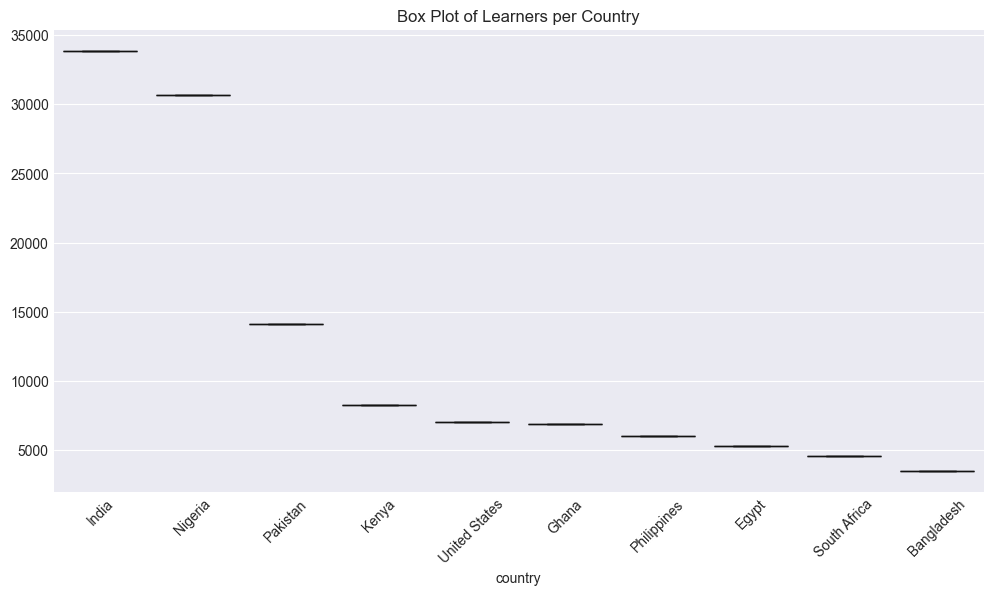

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['country'].value_counts().head(10).index, y=df['country'].value_counts().head(10).values, palette='magma',legend=False,hue=df['country'].value_counts().head(10).index)
plt.title('Box Plot of Learners per Country')
plt.xticks(rotation=45)
plt.show()

*** Density Plot (Learners Across Countries)***

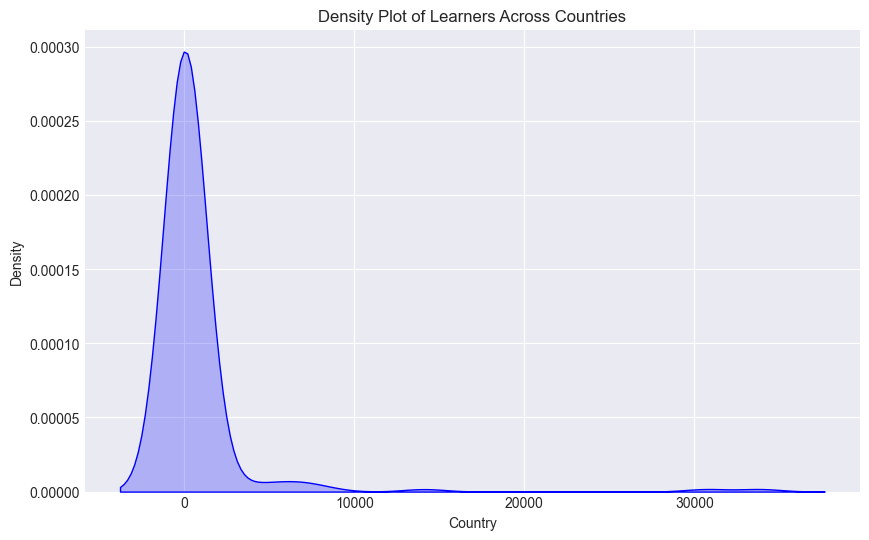

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['country'].value_counts(), fill=True, color='blue')
plt.title("Density Plot of Learners Across Countries")
plt.xlabel("Country")
plt.show()



***Histogram of Degree Occurrences***

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Unknown'),
  Text(1, 0, 'Graduate Student'),
  Text(2, 0, 'Undergraduate Student'),
  Text(3, 0, 'Not In Education'),
  Text(4, 0, 'High School Student'),
  Text(5, 0, 'Other Professional'),
  Text(6, 0, 'Teacher/Educator'),
  Text(7, 0, 'Parent Of Student')])

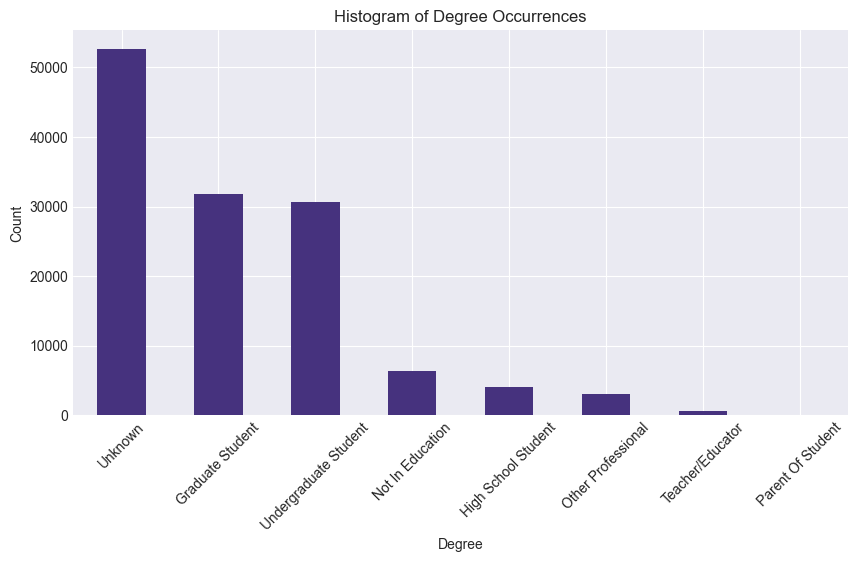

In [12]:
plt.figure(figsize=(10,5))
df['degree'].value_counts().plot(kind='bar')
plt.title('Histogram of Degree Occurrences')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)

***Correlation Heatmap ***

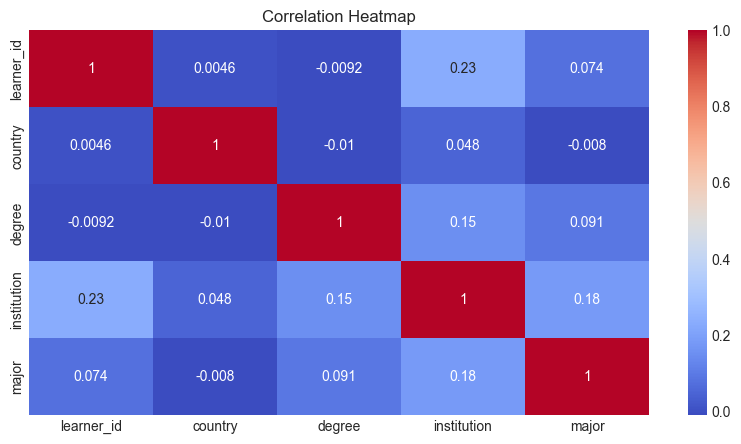

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(df.apply(lambda x: pd.factorize(x)[0]).corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
plt.show()

***Top 10 Majors by Country***

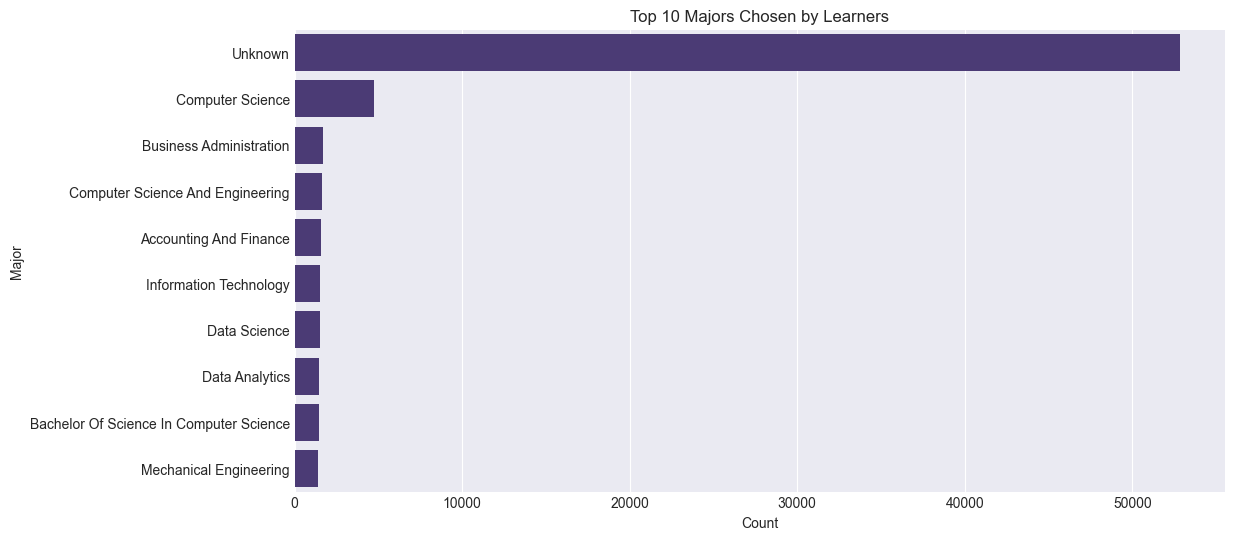

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(y='major', data=df, order=df['major'].value_counts().index[:10])
plt.title('Top 10 Majors Chosen by Learners')
plt.xlabel('Count')
plt.ylabel('Major')
plt.show()

***Country vs Institution Count***

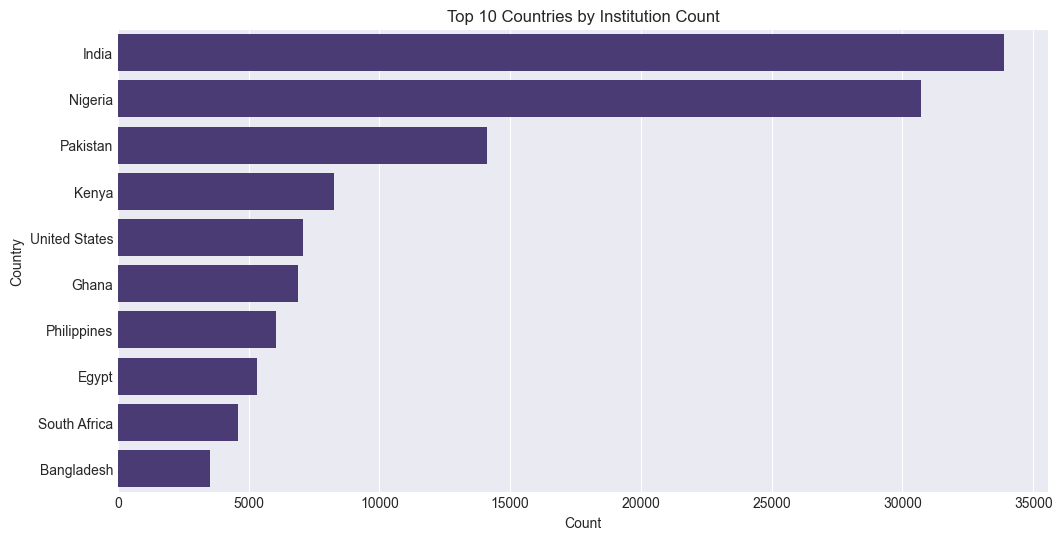

In [15]:
# 7. Country vs Institution Count
plt.figure(figsize=(12,6))
sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:10])
plt.title('Top 10 Countries by Institution Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()


In [16]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Learner_raw Profiling Report")
profile.to_file("output.html")

c:\Users\Chandan N\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 163.12it/s]


In [17]:
from docx import Document
from docx.shared import Inches
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# Load dataset
file_path = "Learner_Raw(in) (1).csv"
df = pd.read_csv(file_path)

# Data Cleaning
df.fillna("Unknown", inplace=True)
for col in ['country', 'degree', 'institution', 'major']:
    df[col] = df[col].str.title()
df.drop_duplicates(inplace=True)

# Create Word Document
doc = Document()
doc.add_heading('📊 Data Cleaning & Visualization Report', level=1)

# Introduction
doc.add_paragraph("This report presents an exploratory data analysis (EDA) of the given dataset, "
                  "including data cleaning steps and various visualizations.")

# Data Cleaning Section
doc.add_heading('1. Data Cleaning', level=2)
doc.add_paragraph(f"Total Records: {df.shape[0]} \nTotal Columns: {df.shape[1]}")
doc.add_paragraph("Steps taken:")
doc.add_paragraph("✔ Filled missing values with 'Unknown' \n✔ Standardized text columns \n✔ Removed duplicates.")

# Set up figure save directory
if not os.path.exists("report_images"):
    os.makedirs("report_images")

# --- Bar Plot: Top 10 Countries ---
plt.figure(figsize=(12, 6))
sns.countplot(y=df['country'], order=df['country'].value_counts().index[:10], palette='coolwarm')
plt.title('Top 10 Countries with Most Learners')
plt.xlabel('Number of Learners')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
img_path = "report_images/top_countries.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('2. Top 10 Countries with Most Learners', level=2)
doc.add_paragraph("The following bar chart represents the top 10 countries where most learners are from.")
doc.add_picture(img_path, width=Inches(6))

# --- Pie Chart: Degree Distribution ---
degree_counts = df['degree'].value_counts().head(5)
plt.figure(figsize=(8, 8))
plt.pie(degree_counts, labels=degree_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Top 5 Degrees Distribution")
img_path = "report_images/degree_distribution.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('3. Degree Distribution', level=2)
doc.add_paragraph("The pie chart below represents the distribution of the top 5 degree types among learners.")
doc.add_picture(img_path, width=Inches(5))

# --- Word Cloud: Majors ---
text = ' '.join(df['major'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Majors")
img_path = "report_images/wordcloud_majors.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('4. Word Cloud of Majors', level=2)
doc.add_paragraph("This word cloud visually represents the most common majors among learners.")
doc.add_picture(img_path, width=Inches(6))

# --- Box Plot: Learners Per Country ---
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['country'].value_counts().head(10).index, y=df['country'].value_counts().head(10).values, palette='magma')
plt.title('Box Plot of Learners per Country')
plt.xticks(rotation=45)
img_path = "report_images/boxplot_countries.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('5. Box Plot of Learners per Country', level=2)
doc.add_paragraph("This box plot illustrates the distribution of learners across the top 10 countries.")
doc.add_picture(img_path, width=Inches(6))

# --- Density Plot: Learners Across Countries ---
plt.figure(figsize=(10, 6))
sns.kdeplot(df['country'].value_counts(), fill=True, color='blue')
plt.title("Density Plot of Learners Across Countries")
plt.xlabel("Country")
img_path = "report_images/density_countries.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('6. Density Plot of Learners Across Countries', level=2)
doc.add_paragraph("The density plot below shows the learner distribution across different countries.")
doc.add_picture(img_path, width=Inches(6))

# --- Histogram of Degree Occurrences ---
plt.figure(figsize=(10,5))
df['degree'].value_counts().plot(kind='bar', color='purple')
plt.title('Histogram of Degree Occurrences')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=45)
img_path = "report_images/histogram_degrees.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('7. Histogram of Degree Occurrences', level=2)
doc.add_paragraph("The histogram below shows the frequency of different degrees among learners.")
doc.add_picture(img_path, width=Inches(6))

# --- Correlation Heatmap ---
plt.figure(figsize=(10,5))
sns.heatmap(df.apply(lambda x: pd.factorize(x)[0]).corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
img_path = "report_images/correlation_heatmap.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('8. Correlation Heatmap', level=2)
doc.add_paragraph("The correlation heatmap below shows relationships between different categorical variables.")
doc.add_picture(img_path, width=Inches(6))

# --- Top 10 Majors by Country ---
plt.figure(figsize=(12,6))
sns.countplot(y='major', data=df, order=df['major'].value_counts().index[:10])
plt.title('Top 10 Majors Chosen by Learners')
plt.xlabel('Count')
plt.ylabel('Major')
img_path = "report_images/top_majors.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('9. Top 10 Majors Chosen by Learners', level=2)
doc.add_paragraph("This bar chart displays the top 10 majors preferred by learners.")
doc.add_picture(img_path, width=Inches(6))

# --- Country vs Institution Count ---
plt.figure(figsize=(12,6))
sns.countplot(y='country', data=df, order=df['country'].value_counts().index[:10])
plt.title('Top 10 Countries by Institution Count')
plt.xlabel('Count')
plt.ylabel('Country')
img_path = "report_images/country_institution.png"
plt.savefig(img_path)
plt.close()

doc.add_heading('10. Country vs Institution Count', level=2)
doc.add_paragraph("This visualization represents the number of institutions in the top 10 countries.")
doc.add_picture(img_path, width=Inches(6))

# Conclusion
doc.add_heading('11. Conclusion', level=2)
doc.add_paragraph("From the analysis, we observe the following key insights:")
doc.add_paragraph("- The highest number of learners are from Nigeria, Kenya, and Bangladesh.")
doc.add_paragraph("- The most common degrees include undergraduate and graduate programs.")
doc.add_paragraph("- Many learners prefer majors in engineering and sustainability.")
doc.add_paragraph("These insights help in understanding the trends in education preferences across different regions.")

# Save the report
report_path = "Learner_Report.docx"
doc.save(report_path)

print(f"✅ Report successfully saved at: {report_path}")


ModuleNotFoundError: No module named 'exceptions'